In [91]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper, WikipediaAPIWrapper


In [92]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2,
                                    doc_content_chars_max=500)

arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv,
                      description="Query Arxiv Papers")

print(arxiv.name)

arxiv


In [93]:
arxiv.invoke("Attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [94]:
api_wrapper_wikipedia = WikipediaAPIWrapper(
    top_k_results=1,
    doc_content_chars_max=500
)

wikipedia = WikipediaQueryRun(
    api_wrapper=api_wrapper_wikipedia,
    description="Query Wikipedia"
)

print(wikipedia.name)

wikipedia


In [95]:
from langchain_community.tools import TavilySearchResults
tavily = TavilySearchResults()

In [96]:
tavily.invoke("Provide me the Recent AI News")

[{'title': 'AI News | Latest News | Insights Powering AI-Driven Business Growth',
  'url': 'https://www.artificialintelligence-news.com',
  'content': "Finance AI\n\nAugust 26, 2025\n\n### Google’s Veo 3 AI video creation tools are now widely available\n\nAI in Action\n\nJuly 29, 2025\n\n#### Computer Vision\n\n### Microsoft’s Majorana 2 quantum chip is also a case study for agentic AI in R&D\n\nInside AI\n\nJune 3, 2026\n\n### US and Japan announce sweeping AI and tech collaboration\n\nArtificial Intelligence\n\nApril 11, 2024\n\n### UK and Canada sign AI compute agreement\n\nArtificial Intelligence\n\nJanuary 31, 2024\n\n#### Machine Learning\n\n### Aviva deploys AI to stop £230M in sophisticated insurance fraud\n\nAI in Action\n\nJune 8, 2026\n\n### Google folds Display Ads into AI-first Demand Gen platform\n\nMarketing AI\n\nMay 27, 2026\n\n### IDC: How EMEA CIOs can jumpstart AI rollouts\n\nGovernance, Regulation & Policy\n\nApril 29, 2026\n\n#### Enterprise [...] April 29, 2026\n

In [97]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

#### Combine All The Tools

### Tavily, Arxiv, Wikipedia

### Initilize The LLM Model

In [98]:
tools = [arxiv, wikipedia, tavily]

In [99]:


from langchain_groq import ChatGroq

llm = ChatGroq(
    model="llama-3.3-70b-versatile"
)

In [100]:
llm.invoke("What is AI")

AIMessage(content='**Artificial Intelligence (AI)** is a field of computer science that focuses on creating intelligent machines that can think, learn, and act like humans. AI involves the development of algorithms, statistical models, and computer programs that enable machines to perform tasks that typically require human intelligence, such as:\n\n1. **Reasoning and problem-solving**: AI systems can analyze data, identify patterns, and make decisions based on that analysis.\n2. **Learning**: AI systems can learn from data and improve their performance over time.\n3. **Perception**: AI systems can interpret and understand data from sensors, such as images, speech, and text.\n4. **Natural Language Processing (NLP)**: AI systems can understand, generate, and process human language.\n\n**Types of AI:**\n\n1. **Narrow or Weak AI**: Designed to perform a specific task, such as image recognition, language translation, or playing chess.\n2. **General or Strong AI**: A hypothetical AI system t

In [101]:
llm_with_tools = llm.bind_tools(tools = tools)

In [102]:
llm_with_tools.invoke("What is The Recent News of AI")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'g6zzh1sc6', 'function': {'arguments': '{"query":"Recent news of AI"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 392, 'total_tokens': 413, 'completion_time': 0.057880511, 'completion_tokens_details': None, 'prompt_time': 0.021116693, 'prompt_tokens_details': None, 'queue_time': 0.049828176, 'total_time': 0.078997204}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eb03d-2b29-7fa1-a0da-1e0a67517574-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'Recent news of AI'}, 'id': 'g6zzh1sc6', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 392, 'output_tokens': 21, 'total_tokens': 413})

In [103]:
llm_with_tools.invoke("What is The Latest Reserach on Quantum Computing")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'ppbj7c7y0', 'function': {'arguments': '{"query":"latest research on quantum computing"}', 'name': 'arxiv'}, 'type': 'function'}, {'id': 'hf16hwccn', 'function': {'arguments': '{"query":"latest research on quantum computing"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 40, 'prompt_tokens': 395, 'total_tokens': 435, 'completion_time': 0.121649535, 'completion_tokens_details': None, 'prompt_time': 0.019661894, 'prompt_tokens_details': None, 'queue_time': 0.055624832, 'total_time': 0.141311429}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eb03d-2bfc-7d50-baf0-9a936cccf690-0', tool_calls=[{'name': 'arxiv', 'args': {'query': 'latest research on quantum computing'}, 'id': 'ppbj7c7y0', 'type': 'tool_cal

In [104]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
from typing import List

In [105]:



from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage

class State(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    

In [106]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

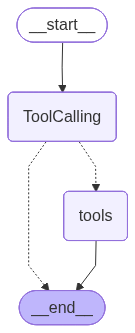

In [116]:
def ToolCalling(state):
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": state["messages"] + [response]}
    


builder = StateGraph(State)
builder.add_node("ToolCalling", ToolCalling)
builder.add_node("tools", ToolNode(tools))


builder.add_edge(START, "ToolCalling")
builder.add_conditional_edges(
    "ToolCalling",
    tools_condition
)

builder.add_edge("tools", END)
graph= builder.compile()



display(Image(graph.get_graph().draw_mermaid_png()))

In [117]:


from langchain_core.messages import HumanMessage

messages = graph.invoke({
    "messages": "1706.03762"})

for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (2hkypw9e5)
 Call ID: 2hkypw9e5
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, base


In [119]:
from langchain_core.messages import HumanMessage

graph.invoke({
    "messages": "What is Machine Learning?"
})

BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=wikipedia{"query": "Machine Learning"}</function>'}}